这三个库（Seaborn, Plotly, Pandas plotting）是 Python 数据可视化生态系统的核心。掌握它们能极大地提升你的数据分析和展示能力。
我将为你提供一个全面的、分步的详细教程。

本教程结构如下：

Matplotlib：万物的基础
Seaborn 和 Plotly 对 Matplotlib 的主要改进

教程一：Seaborn 详细教程 (用于统计与美学)
教程二：Plotly 详细教程 (用于交互与网络)
教程三：Pandas 自带作图教程 (用于快速探索)


#### 总结：何时使用哪个库？


1. Matplotlib：万物的基础  
   
在学习其他库之前，必须了解 Matplotlib 是 Python 可视化的“祖父级”库。几乎所有其他库，包括 Seaborn 和 Pandas Plotting，底层都是构建在 Matplotlib 之上的。

* 优点：功能极其强大，控制力极强。你可以自定义图表的任何一个微小细节。
* 缺点：API 相对底层和繁琐，有时需要写很多代码才能实现一个简单的图表，且默认样式不够美观。


2. Seaborn 和 Plotly 对 Matplotlib 的主要改进  
   
这两个库的出现，就是为了解决 Matplotlib 的缺点。


Seaborn 的改进：  

1.1. 更简洁的 API：用更少的代码创建更复杂的统计图表。例如，在 Matplotlib 中画一个带回归线的散点图可能需要多行代码，而在 Seaborn 中通常只需一行。  

1.2. 更美观的默认样式：Seaborn 的默认主题、调色板和样式远比 Matplotlib 的现代和美观，几乎无需调整即可生成“出版级”的图表。 

1.3. 专注于统计可视化：Seaborn 内置了许多专门用于展示统计关系的功能，如分布图、分类数据图、线性模型可视化等，这是 Matplotlib 所不具备的。  

1.4. 与 Pandas 的深度集成：Seaborn 的函数设计能够非常自然地接受 Pandas DataFrame 作为输入，并能轻松地使用列名来分配颜色、大小、样式等。 

一句话总结 Seaborn：让 Matplotlib 变得更简单、更美观，并专注于统计分析。  


Plotly 的改进：  

2.1. 原生交互性 (Interactive)：这是 Plotly 最大的优势。用 Plotly 生成的图表是交互式的。你可以用鼠标悬停查看数据、缩放、平移、点击图例来隐藏/显示数据，而这一切都无需额外代码。Matplotlib 和 Seaborn 生成的默认是静态图片。

2.2. Web 原生：Plotly 的图表是基于 JSON 和 JavaScript (Plotly.js) 构建的。这意味着你可以轻松地将图表嵌入到网页、在线报告和 Dash 应用中，它们看起来和行为都像现代的网络应用元素。

2.3. 更现代的图表类型：Plotly 提供了许多 Matplotlib/Seaborn 不容易实现的现代图表，如旭日图 (Sunburst)、平行坐标图、三维网络图、地理地图（Choropleth maps）等。

2.4. 声明式 API (Plotly Express)：Plotly Express 提供了一个极其简洁的声明式 API，你只需“声明”你想要的数据和映射方式，它就会为你生成一个完整的、交互式的图表。

一句话总结 Plotly：它不是对 Matplotlib 的“改进”，而是一个全新的、为交互式和网络时代打造的可视化引擎。



#### 教程一：Seaborn 详细教程
目标：用最少的代码创建美观的统计图表。

第一步：安装和导入


!pip install seaborn matplotlib pandas

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 

第二步：核心概念 - Figure-level vs. Axes-level
* Axes-level 函数：在一个已经存在的 matplotlib.pyplot.Axes 对象上绘图（例如 scatterplot, histplot, boxplot）。你可以精确控制每个子图画什么。
* Figure-level 函数：会自己创建一个 Matplotlib Figure 和 Axes，并能轻松创建分面网格（多个子图）。例如 relplot, displot, catplot。

第三步：加载数据

Seaborn 自带一些示例数据集，非常适合学习。

In [3]:
# 加载 "tips" (小费) 数据集
tips = sns.load_dataset("tips")
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [4]:
tips.shape

(244, 7)

第四步：常用图表实战
1. 分布图 (Distribution Plots) - 查看单个变量的分布
直方图 (histplot)

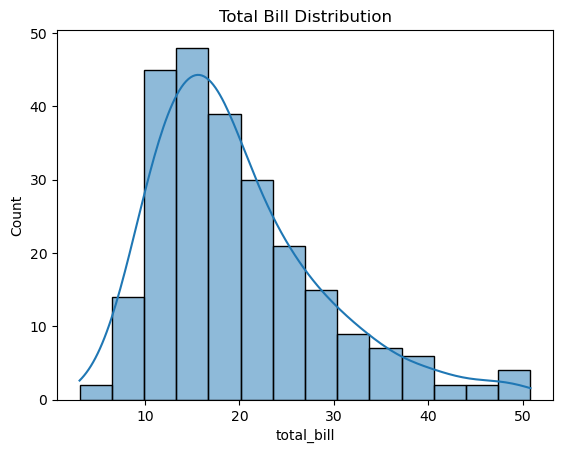

In [5]:
sns.histplot(data=tips, x="total_bill", kde=True) # kde=True 会加上KDE曲线
plt.title("Total Bill Distribution")
plt.show()

核密度估计图 (kdeplot) - 平滑版的直方图

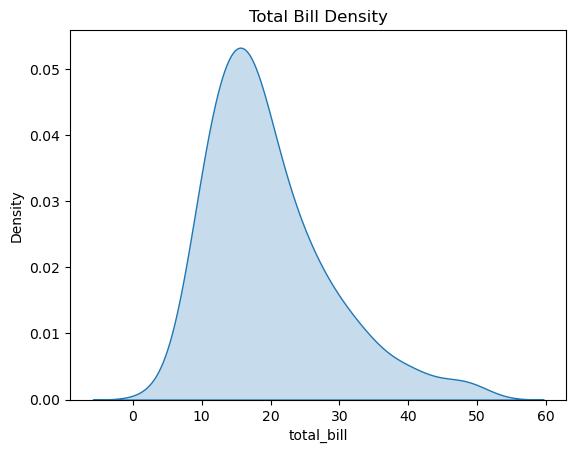

In [6]:
sns.kdeplot(data=tips, x="total_bill", fill=True) # fill=True 填充曲线下方
plt.title("Total Bill Density")
plt.show()

2. 关系图 (Relational Plots) - 查看两个变量间的关系
散点图 (scatterplot)
使用 hue 参数引入第三个分类变量，用颜色区分。

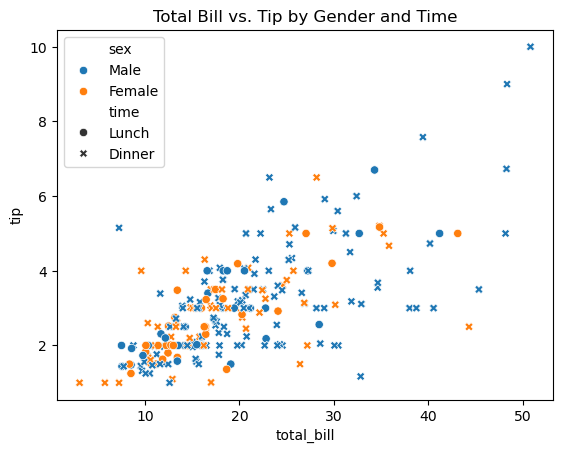

In [7]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex", style="time")
plt.title("Total Bill vs. Tip by Gender and Time")
plt.show()